In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


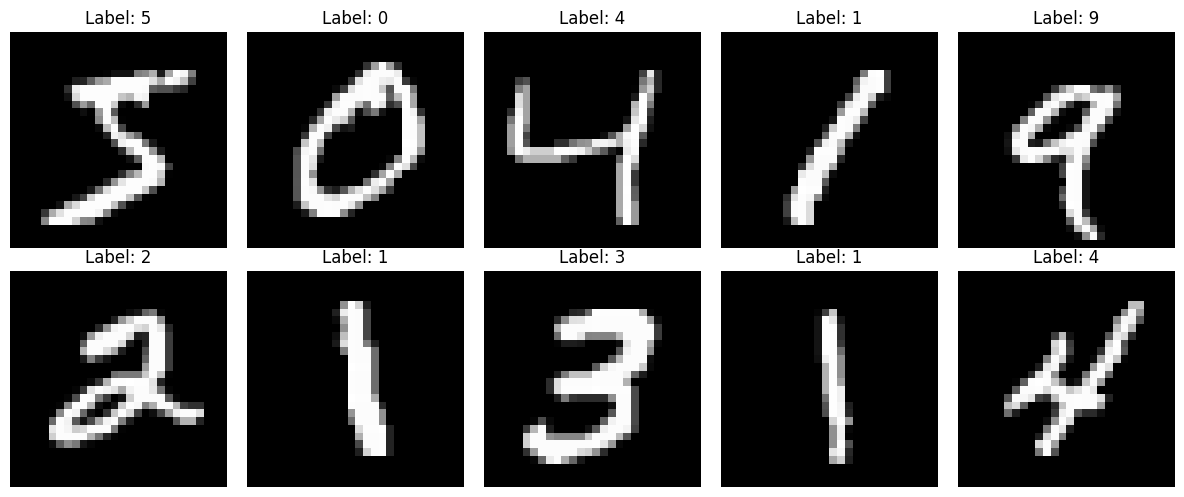

In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Print dataset information
print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Testing Labels Shape  :", y_test.shape)

# Display the first 10 training images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [3]:
# Normalize pixel values (0 to 255 --> 0 to 1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images for CNN
# Original shape: (60000, 28, 28)
# New shape: (60000, 28, 28, 1)

x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))

# One-Hot Encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Check the new shapes
print("Training Images Shape :", x_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Images Shape : (60000, 28, 28, 1)
Testing Images Shape  : (10000, 28, 28, 1)
Training Labels Shape : (60000, 10)
Testing Labels Shape  : (10000, 10)


In [4]:
# Build CNN Model

model = Sequential([

    # First Convolution Layer
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    # Second Convolution Layer
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer (10 digits: 0-9)
    Dense(10, activation='softmax')
])

# Display Model Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compile the CNN model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9271 - loss: 0.2398 - val_accuracy: 0.9827 - val_loss: 0.0570
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9752 - loss: 0.0857 - val_accuracy: 0.9866 - val_loss: 0.0483
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9807 - loss: 0.0622 - val_accuracy: 0.9875 - val_loss: 0.0458
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9847 - loss: 0.0512 - val_accuracy: 0.9899 - val_loss: 0.0358
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9873 - loss: 0.0420 - val_accuracy: 0.9893 - val_loss: 0.0392
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 30ms/step - accuracy: 0.9891 - loss: 0.0358 - val_accuracy: 0.9896 - val_loss: 0.0372
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9895 - loss: 0.0335 - val_accuracy: 0.9910 - val_loss: 0.0348
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 31ms/step - accuracy: 0.9907 -

In [6]:
# Evaluate the model on the test dataset

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9921 - loss: 0.0283

Test Loss : 0.028334815055131912
Test Accuracy : 0.9921000003814697


In [7]:
# Predict probabilities
predictions = model.predict(x_test)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [8]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [9]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[ 977    0    0    0    0    0    2    0    0    1]
 [   0 1133    1    0    0    0    1    0    0    0]
 [   1    2 1026    0    0    0    0    3    0    0]
 [   0    0    1 1004    0    3    0    0    2    0]
 [   0    0    0    0  975    0    3    0    0    4]
 [   0    0    0    2    0  887    1    0    1    1]
 [   2    2    0    0    1    3  950    0    0    0]
 [   0    3    9    0    0    0    0 1013    1    2]
 [   2    0    3    1    1    0    0    1  964    2]
 [   0    1    0    1    4    6    0    1    4  992]]


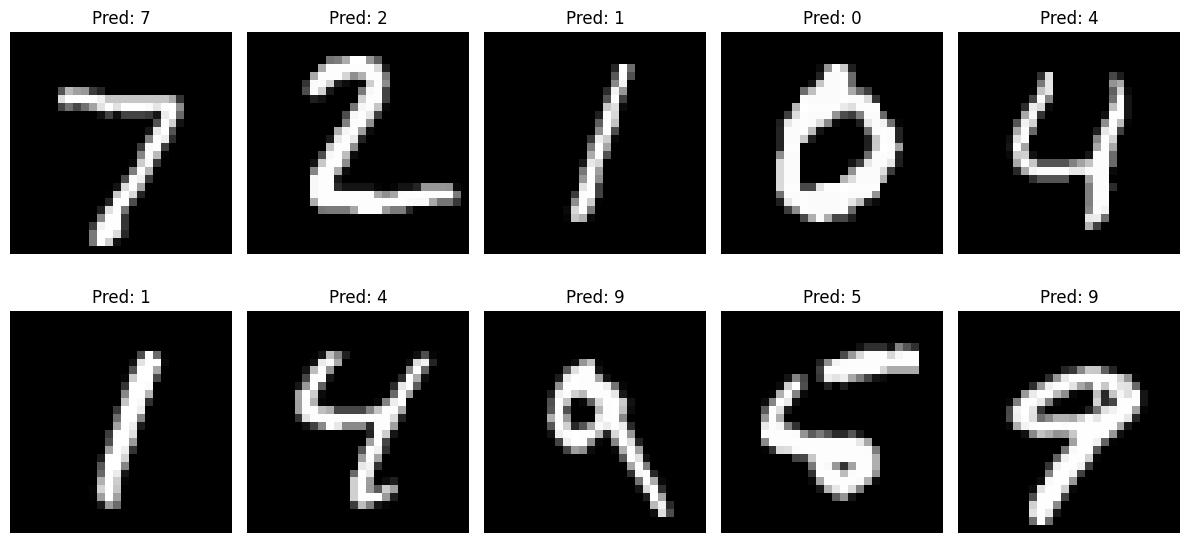

In [10]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

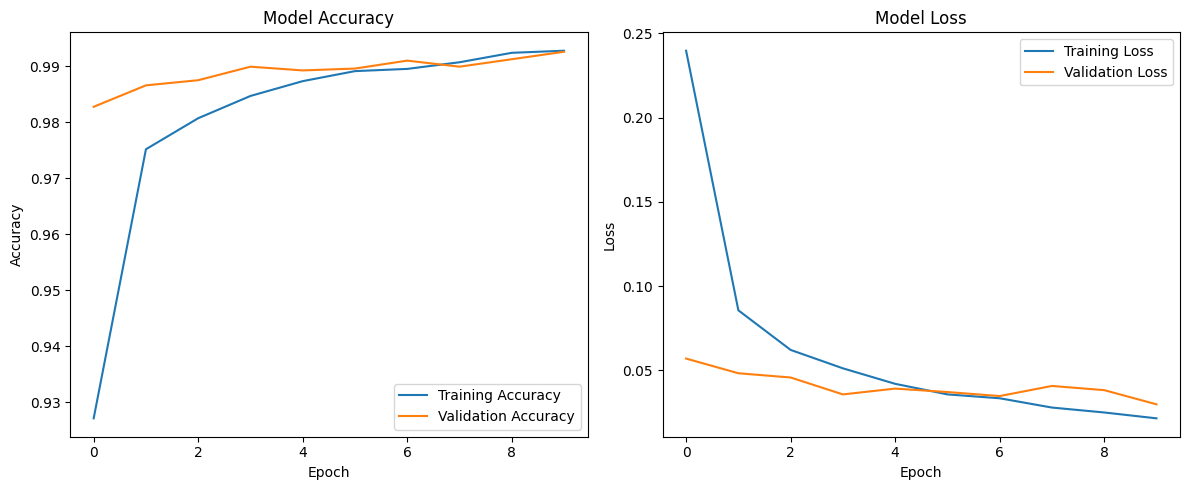

In [11]:
# Plot Accuracy and Loss

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

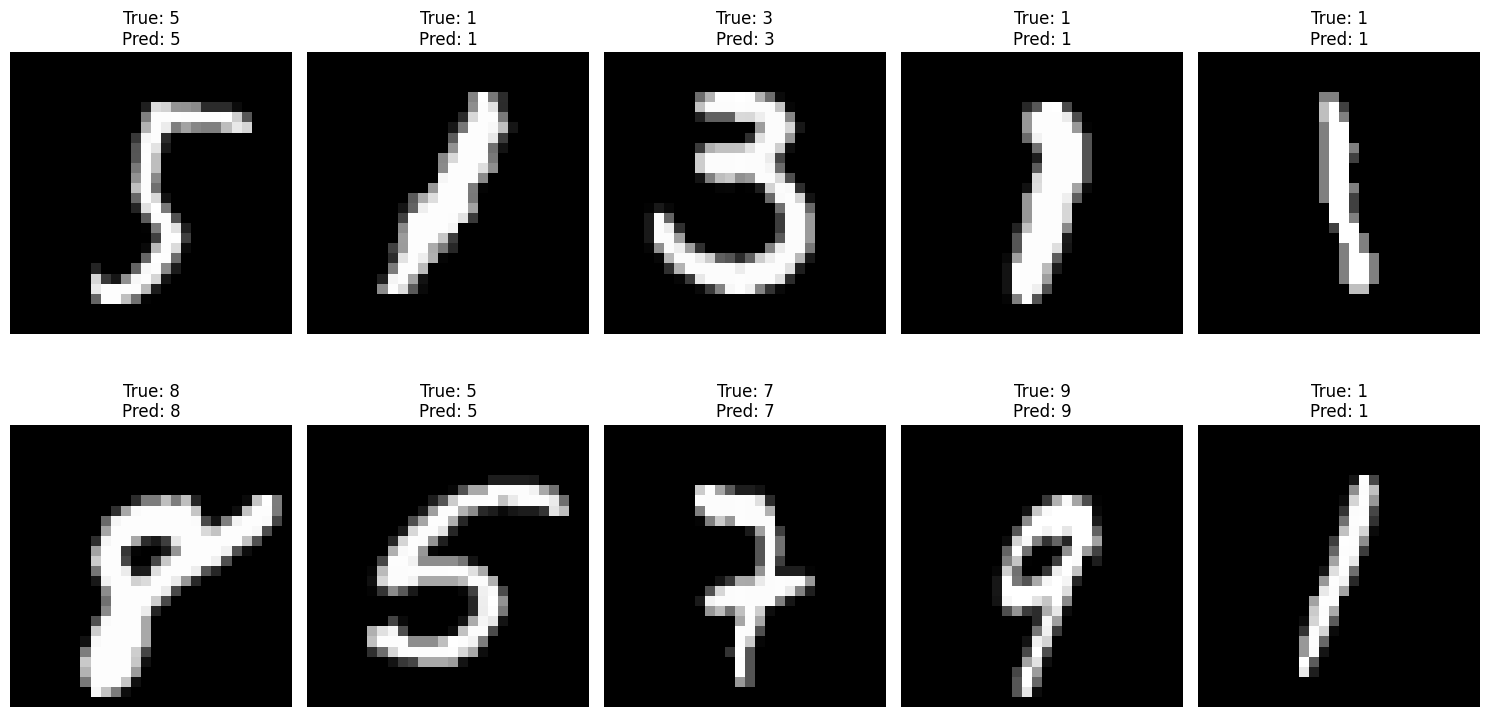

In [12]:
# Display predictions on random test images

plt.figure(figsize=(15,8))

random_indices = np.random.randint(0, len(x_test), 10)

for i, idx in enumerate(random_indices):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Save the trained model

model.save("handwritten_digit_cnn.h5")

print("Model saved successfully!")

Model saved successfully!


In [14]:
from tensorflow.keras.models import load_model

loaded_model = load_model("handwritten_digit_cnn.h5")